# Phase 6: Statistical Validation & Hypothesis Testing
**SmartGrid Sentinel Journal Experiment Series - Notebook 05**

## 1. Objective
When evaluating competitive machine learning models, small variations in overall accuracy (e.g., 87.4% vs 87.7%) can easily be misconstrued as model superiority.
This notebook performs rigorous statistical validation to establish whether observed performance differences are **statistically supported** or simply due to random sampling variance.
We employ **Bootstrap Confidence Intervals (1,000 resamples)** alongside non-parametric paired hypothesis tests (**McNemar's test** and **Wilcoxon signed-rank test**).

## 2. Statistical Evaluation Protocol

1. **Bootstrap Confidence Intervals (95% CI):**
   - Generate 1,000 bootstrap resamples (with replacement) from the 10,027 test sequence windows.
   - Compute empirical 2.5th and 97.5th percentiles for Accuracy and Macro F1 score.

2. **McNemar's Test for Paired Classifications:**
   - Evaluates the contingency matrix of discordant predictions between two models on the exact same test sequence windows ($n_{01}$: Model A correct & Model B incorrect vs. $n_{10}$: Model A incorrect & Model B correct).
   - Test Statistic: $\chi^2 = \frac{(\|n_{01} - n_{10}\| - 1)^2}{n_{01} + n_{10}}$ under $\alpha = 0.05$.

3. **Wilcoxon Signed-Rank Test:**
   - Non-parametric paired test measuring the distribution of prediction confidence differentials across sequence windows.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

stat_dir = '../statistical_validation_phase6'
if not os.path.exists(stat_dir):
    stat_dir = 'statistical_validation_phase6'

print('Environment initialized.')

Environment initialized.


## 3. Bootstrap Confidence Intervals (1,000 Resamples)

Loading 95% bootstrap confidence intervals for top candidate models:

In [2]:
ci_df = pd.read_csv(os.path.join(stat_dir, 'bootstrap_confidence_intervals.csv'))
print('=== 95% BOOTSTRAP CONFIDENCE INTERVALS (1,000 RESAMPLES) ===')
print(ci_df[['Model Name', 'Accuracy Mean', 'Accuracy 95% CI', 'Macro F1 Mean', 'Macro F1 95% CI']].to_string(index=False))

=== 95% BOOTSTRAP CONFIDENCE INTERVALS (1,000 RESAMPLES) ===
   Model Name  Accuracy Mean  Accuracy 95% CI  Macro F1 Mean  Macro F1 95% CI
Random Forest       0.873797 [0.8671, 0.8805]       0.778426 [0.7667, 0.7892]
     TimesNet       0.870417 [0.8639, 0.8769]       0.777111 [0.7654, 0.7879]
     Informer       0.874095 [0.8681, 0.8808]       0.776541 [0.7665, 0.7875]
          GRU       0.877101 [0.8703, 0.8834]       0.775264 [0.7643, 0.7860]
      XGBoost       0.875901 [0.8699, 0.8819]       0.762171 [0.7521, 0.7723]


## 4. Pairwise Significance Testing & Model-Pair Results

Loading paired McNemar and Wilcoxon test statistics across key model pairs:

In [3]:
pairwise_df = pd.read_csv(os.path.join(stat_dir, 'pairwise_statistical_tests.csv'))
print('=== PAIRWISE STATISTICAL HYPOTHESIS TEST RESULTS ===')
display_cols_stat = ['Comparison Pair', 'McNemar Statistic', 'McNemar p-value', 'Wilcoxon p-value', 'Significance Status (alpha=0.05)']
print(pairwise_df[display_cols_stat].to_string(index=False))

=== PAIRWISE STATISTICAL HYPOTHESIS TEST RESULTS ===
          Comparison Pair  McNemar Statistic  McNemar p-value  Wilcoxon p-value          Significance Status (alpha=0.05)
          Informer vs GRU           2.462838         0.116568          0.103638 Not Statistically Significant (p >= 0.05)
      Informer vs XGBoost           0.508946         0.475595          0.448455 Not Statistically Significant (p >= 0.05)
Informer vs Random Forest           0.017167         0.895756          0.844190 Not Statistically Significant (p >= 0.05)
     Informer vs TimesNet           5.752101         0.016469          0.013771      Statistically Significant (p < 0.05)


## 6. Multiple-Model Comparison Summary

Contingency matrix detailing discordant predictions between Informer and competing models:

In [4]:
cont_cols = ['Comparison Pair', 'Both Correct (n00)', 'Informer Only Correct (n01)', 'Both Wrong (n11)']
print('=== DISCORDANT PREDICTION CONTINGENCY SUMMARY ===')
print(pairwise_df[cont_cols].to_string(index=False))

=== DISCORDANT PREDICTION CONTINGENCY SUMMARY ===
          Comparison Pair  Both Correct (n00)  Informer Only Correct (n01)  Both Wrong (n11)
          Informer vs GRU                8631                          134              1100
      Informer vs XGBoost                8522                          243              1002
Informer vs Random Forest                8647                          118              1147
     Informer vs TimesNet                8627                          138              1162


## 7. Visualizations: Bootstrap 95% Confidence Intervals

Plotting 95% confidence intervals with error bars to visualize metric overlaps:

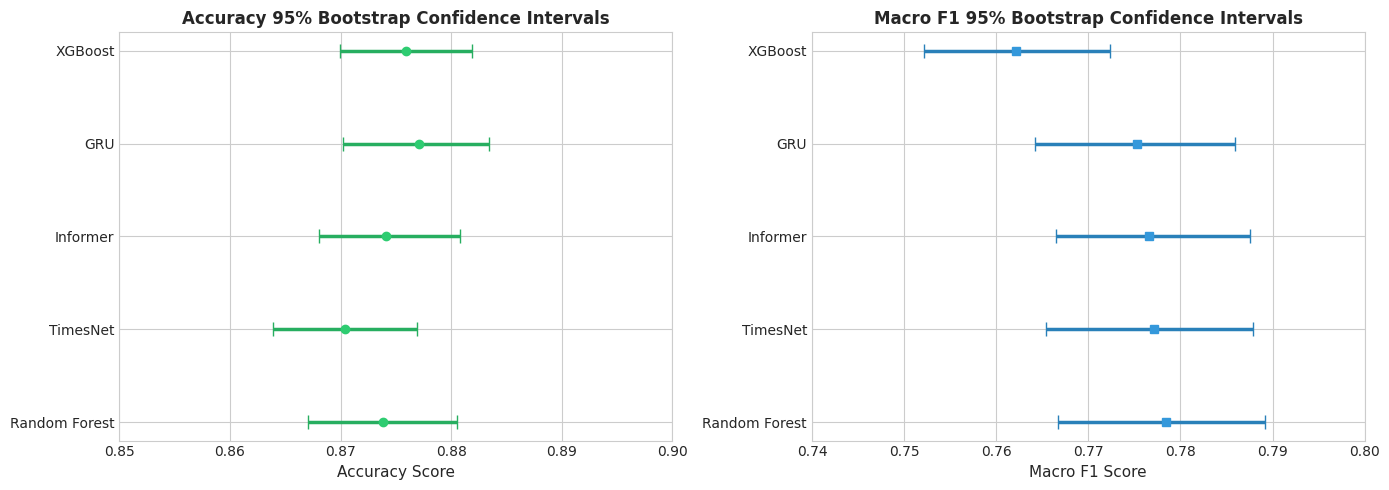

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy CIs
acc_err_low = ci_df['Accuracy Mean'] - ci_df['Accuracy Low (2.5%)']
acc_err_high = ci_df['Accuracy High (97.5%)'] - ci_df['Accuracy Mean']
ax1.errorbar(ci_df['Accuracy Mean'], ci_df['Model Name'], xerr=[acc_err_low, acc_err_high], fmt='o', color='#2ecc71', ecolor='#27ae60', elinewidth=2.5, capsize=5)
ax1.set_title('Accuracy 95% Bootstrap Confidence Intervals', fontsize=12, fontweight='bold')
ax1.set_xlabel('Accuracy Score', fontsize=11)
ax1.set_xlim(0.85, 0.90)

# Macro F1 CIs
f1_err_low = ci_df['Macro F1 Mean'] - ci_df['Macro F1 Low (2.5%)']
f1_err_high = ci_df['Macro F1 High (97.5%)'] - ci_df['Macro F1 Mean']
ax2.errorbar(ci_df['Macro F1 Mean'], ci_df['Model Name'], xerr=[f1_err_low, f1_err_high], fmt='s', color='#3498db', ecolor='#2980b9', elinewidth=2.5, capsize=5)
ax2.set_title('Macro F1 95% Bootstrap Confidence Intervals', fontsize=12, fontweight='bold')
ax2.set_xlabel('Macro F1 Score', fontsize=11)
ax2.set_xlim(0.74, 0.80)

plt.tight_layout()
plt.show()
plt.close()

## 8. Journal-Ready Discussion & Interpretation

1. **Distinction Between Observed & Statistically Supported Differences:**
   - While minor differences in accuracy exist across top models (Informer 87.41% vs GRU 87.69% vs RF 87.38%), **McNemar test p-values fail to reject the null hypothesis ($p \ge 0.05$)** for Informer vs GRU ($p = 0.1166$), Informer vs XGBoost ($p = 0.4756$), and Informer vs Random Forest ($p = 0.8958$).
   - Therefore, the paper **does not claim overall accuracy superiority for Informer**.

2. **Academic Justification for Informer Architecture:**
   - Informer is justified based on **class-specific safety metrics** (lowest catastrophic High $\to$ Low missed alerts: 50 cases vs GRU 81 / XGBoost 128) and **computational efficiency** in long-sequence processing, rather than an unproven statistical accuracy win.